In [878]:
import torch
import numpy  as np
import torch.nn as nn

class SpringEncoderSTEP(nn.Module):
    def __init__(self, dt=1e-3, steps=1000, mass=1.0, embedding_size=128,**kwargs):
        super(SpringEncoderSTEP, self).__init__()
        self.dt = dt
        self.steps = steps
        self.mass = mass  # Scalar mass (assumed the same for all objects)
        self.embedding_size = embedding_size
        self.Tmax = 1000.0
        self.min_k_clip = 1e-5
        self.max_k_clip = 10

    def forward(self, x0, t0,mask):
        """
        Simulates the motion of a spring-mass system over time.
        Arguments:
            x0: Initial positions (Tensor of shape [batch_size])
            t0: Periods (Tensor of shape [batch_size])
            v0: Initial velocities (Tensor of shape [batch_size])
        Returns:
            t_values: Time values (Tensor of shape [steps])
            x_values: Simulated positions (Tensor of shape [batch_size, steps])
        """
        v0 = 0
         
        batch_size ,seqlen, input_size= x0.shape  # Batch size
         
       # print(batch_size,seqlen)
        # Ensure tensors are on the correct device
        x0 = (x0  * mask).squeeze(-1)
        t0 = (t0 * mask).squeeze(-1)

       # v0 = v0.to(self.device) * mask
        # Allocate memory for position and velocity
        x_values = torch.zeros((batch_size,seqlen, self.embedding_size), device=x0.device)
        v_values = torch.zeros((batch_size,seqlen, self.embedding_size), device=x0.device)
       #print(x_values.shape)
        # Compute spring constant k
        k_batch = self.calculate_k(t0) # Shape: [batch_size]
        m_batch = torch.ones_like(k_batch)
        # Time values
        t_values = torch.linspace(1e-5, self.dt *self.steps, self.embedding_size, device=x0.device)
        
        # Set initial conditions
        x_values[:,:, 0] = x0
        v_values[:,:, 0] = v0
        # Time stepping loop using Euler's method
        for i in range(1, self.embedding_size): 
            a = -(k_batch / m_batch) * x_values[:,:, i - 1]  # Acceleration (Hooke's law)
            v_values[:,:, i] =  a * self.dt  + v_values[:,:, i - 1]# Update velocity
            x_values[:,:, i] = x_values[:,:, i - 1] + v_values[:, :,i] * self.dt  # Update position
        #t_values =torch.nn.functional.interpolate(x_values, size=200, mode="linear", align_corners=False)
       # x_values =  torch.nn.functional.interpolate(x_values, size=self.embedding_size, mode="linear", align_corners=False)
        return x_values

    def calculate_k(self, t):
        """Compute the spring constant k given time periods t."""
        n = t/ (2 * torch.pi *self.Tmax)
        #print(n.shape)
        n = torch.clamp(n, self.min_k_clip, self.max_k_clip)  # Clip values
        return 1 / n


 

In [887]:
from torch.utils.data import  DataLoader
from src.data.handlers import SSLDataset

from src.data.modules.LitData  import LitData
from src.data.modules.LitPretrain import LitPretrain

module = LitData(**{'data_root': '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12',
   'use_sampler': False,
   'batch_size': 15,
   'shuffle':True})

train_dataloader = module.train_dataloader()
val_dataloader = module.val_dataloader()

using set train total of idx : 161611 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type train
NOT USING SAMPLER FOR DATASET train
using set validation total of idx : 40698 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type validation
NOT USING SAMPLER FOR DATASET validation


In [888]:
from tqdm import tqdm
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
r_encoder = SpringEncoderSTEP(dt = 1,device=device,steps = 1000,mass=1)
g_encoder = SpringEncoderSTEP(dt = 1,device=device,steps = 1000,mass=1)

DICT = {
    "AGN": 0,
    "QSO": 1,
    "EA": 2,
    "YSO": 3,
    "SNIa": 4,
    "CV/Nova": 5,
    "RRLc": 6,
    "RSCVn": 7,
    "Blazar": 8,
    "SNII": 9,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}
USEFUL_DICT = {}
for key,value in DICT.items():
  USEFUL_DICT[value] = key
save_results = []


r_encoder.eval().to(device = device)
g_encoder.eval().to(device = device)

SpringEncoderSTEP()

In [889]:

for batch in tqdm(val_dataloader):
    b1 = {key:value.to(device = device) for key,value in batch.items()}
    r_encoded_x = r_encoder.forward(b1['data'][:,:,:1],b1['time'][:,:,:1],b1['mask'][:,:,:1]).detach().cpu().numpy()
    g_encoded_x = r_encoder.forward(b1['data'][:,:,1:],b1['time'][:,:,1:],b1['mask'][:,:,1:]).detach().cpu().numpy()
    data = b1['data'].detach().cpu().numpy()
    save_results.append((r_encoded_x,g_encoded_x, b1['labels'].detach().cpu().numpy(),data))
    break


  0%|          | 0/2713 [00:01<?, ?it/s]


/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/matplotlib/colors.py:1405: RuntimeWarning: overflow encountered in divide
  resdat /= (vmax - vmin)
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/matplotlib/colors.py:744: RuntimeWarning: overflow encountered in multiply
  xa *= self.N
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/matplotlib/colors.py:1405: RuntimeWarning: overflow encountered in divide
  resdat /= (vmax - vmin)
/home/mdelafuente/miniconda3/envs/ATAT/lib/python3.12/site-packages/matplotlib/colors.py:744: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


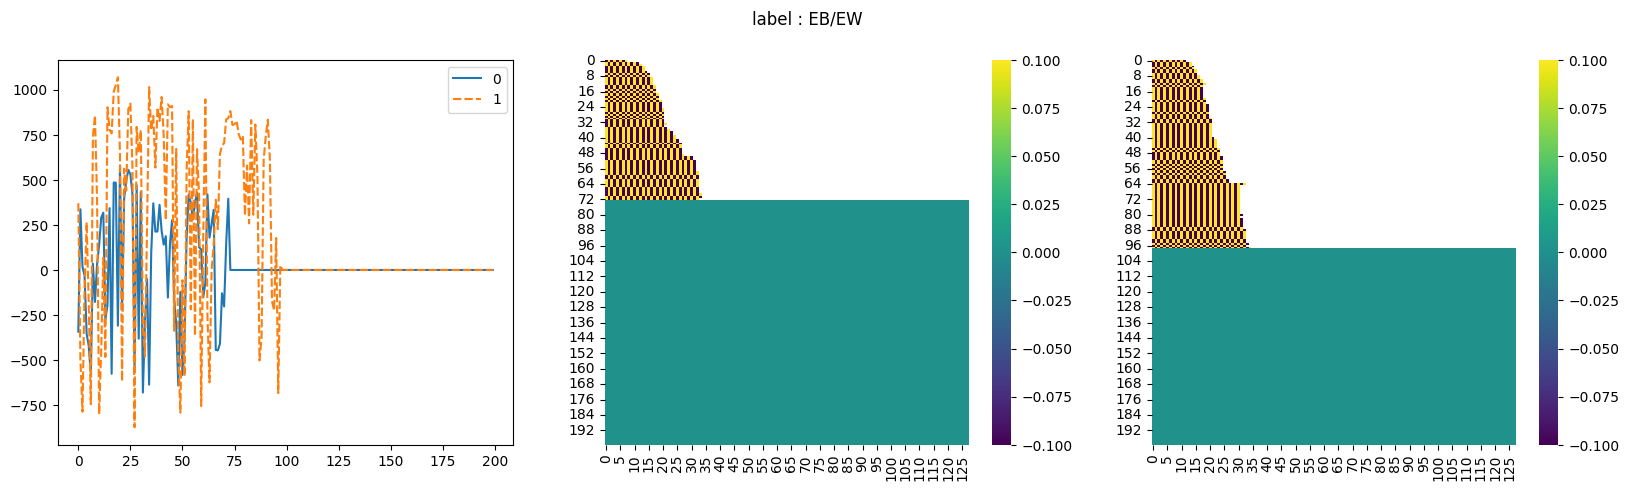

In [890]:
import seaborn as sns
import matplotlib.pyplot as plt
  # Take every second element
show_seqlen = 200
show_emb = 1000
#for i in list(np.random.randint(0,5,5)):
for i in list(range(1)):
    fig = plt.figure(figsize = (20,5))
    #sns.lineplot(b1['data'][i,:show_len],ax = fig.add_subplot(131))
    #r_encoded_x = torch.fill_(r_encoded_x == float('inf'),0)
    s = 0 #np.random.choice(range(0,10))
    
    sns.lineplot(save_results[s][3][i,:show_seqlen,:show_emb],ax = fig.add_subplot(131))
    sns.heatmap(save_results[s][0][i,:show_seqlen,:show_emb],ax = fig.add_subplot(132),cmap = 'viridis')
    sns.heatmap(save_results[s][1][i,:show_seqlen,:show_emb],ax = fig.add_subplot(133),cmap = 'viridis')
    #sns.heatmap(rmask[s,:show_len].detach().cpu().numpy(),ax = fig.add_subplot(133),cmap = 'viridis')
    plt.suptitle(f'label : {USEFUL_DICT[int(save_results[s][2][i])]}')
    plt.show()

In [922]:
import torch
import numpy  as np
import torch.nn as nn

class SpringEncoderANA(nn.Module):
    def __init__(self, dt=1e-5, steps=1000, mass=1.0, embedding_size=128,**kwargs):
        super(SpringEncoderANA, self).__init__()
        self.dt = dt
        self.steps = steps
        self.mass = mass  # Scalar mass (assumed the same for all objects)
        self.embedding_size = embedding_size
        self.Tmax = 1000.0
        self.min_k_clip = 1e-5
        self.max_k_clip = 10

    def forward(self, x0, t0,mask):
        """
        Simulates the motion of a spring-mass system over time.
        Arguments:
            x0: Initial positions (Tensor of shape [batch_size])
            t0: Periods (Tensor of shape [batch_size])
            v0: Initial velocities (Tensor of shape [batch_size])
        Returns:
            t_values: Time values (Tensor of shape [steps])
            x_values: Simulated positions (Tensor of shape [batch_size, steps])
        """
        v0 = 0
         
        batch_size ,seqlen, input_size= x0.shape  # Batch size 
        
        t = torch.linspace(0,self.dt*self.steps,self.steps,device = t0.device).repeat(1,seqlen,1) 
        k = self.calculate_k(t0)
        w = k
        #print((x0*torch.cos(t)).shape)
        out = x0*torch.cos(w*t/self.mass + t0.repeat(1,1,self.steps) )
        return torch.nn.functional.interpolate(out, size=self.embedding_size, mode="linear", align_corners=False)

    def calculate_k(self, t):
        """Compute the spring constant k given time periods t."""
        n = t/ (2 * torch.pi * self.Tmax)
        #print(n.shape)
        n = torch.clamp(n, self.min_k_clip, self.max_k_clip)  # Clip values
        return 1 / n


 

In [926]:
from tqdm import tqdm
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
r_encoder = SpringEncoderANA(dt = 1,device=device,steps = 1000,mass=1.)
g_encoder = SpringEncoderANA(dt = 1,device=device,steps = 1000,mass=1.0)

DICT = {
    "AGN": 0,
    "QSO": 1,
    "EA": 2,
    "YSO": 3,
    "SNIa": 4,
    "CV/Nova": 5,
    "RRLc": 6,
    "RSCVn": 7,
    "Blazar": 8,
    "SNII": 9,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}
USEFUL_DICT = {}
for key,value in DICT.items():
  USEFUL_DICT[value] = key
save_results = []


r_encoder.eval().to(device = device)
g_encoder.eval().to(device = device)

SpringEncoderANA()

In [927]:


for batch in tqdm(val_dataloader):
    b1 = {key:value.to(device = device) for key,value in batch.items()}
    r_encoded_x = r_encoder.forward(b1['data'][:,:,:1],b1['time'][:,:,:1],b1['mask'][:,:,:1]).detach().cpu().numpy()
    g_encoded_x = r_encoder.forward(b1['data'][:,:,1:],b1['time'][:,:,1:],b1['mask'][:,:,1:]).detach().cpu().numpy()

    
    #print(r_encoded_x.shape)
    data = b1['data'].detach().cpu().numpy()
    save_results.append((r_encoded_x,g_encoded_x, b1['labels'].detach().cpu().numpy(),data))


100%|██████████| 2713/2713 [00:21<00:00, 125.60it/s]


(15, 200, 128)
(15, 200, 128)


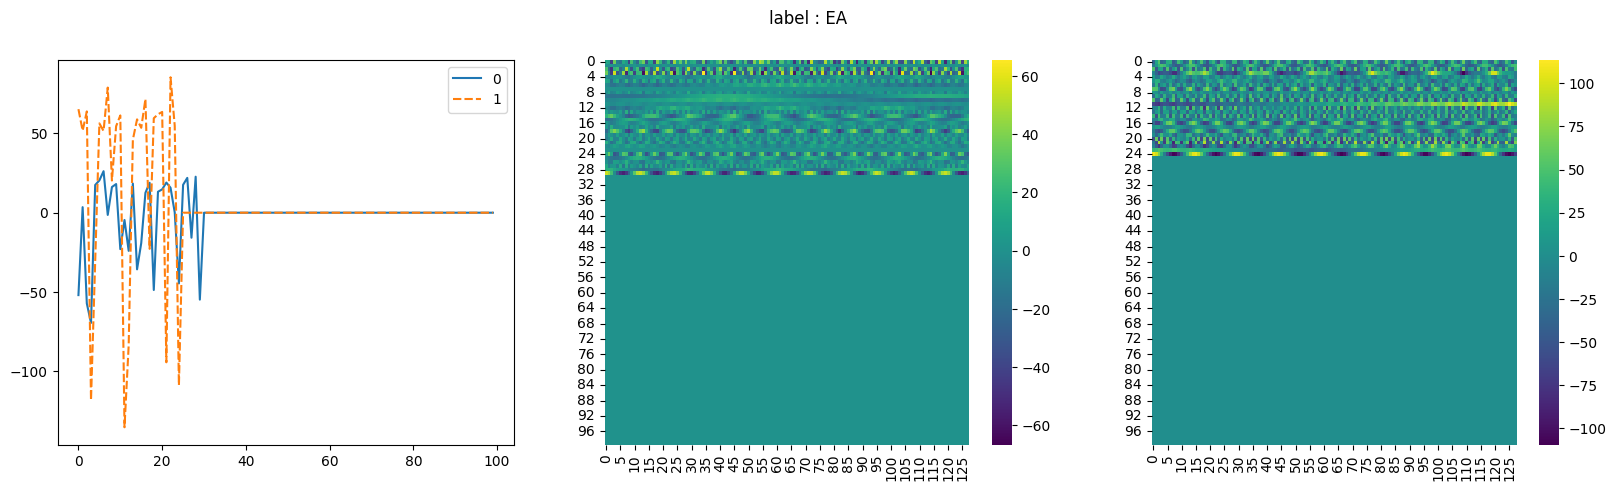

(15, 200, 128)


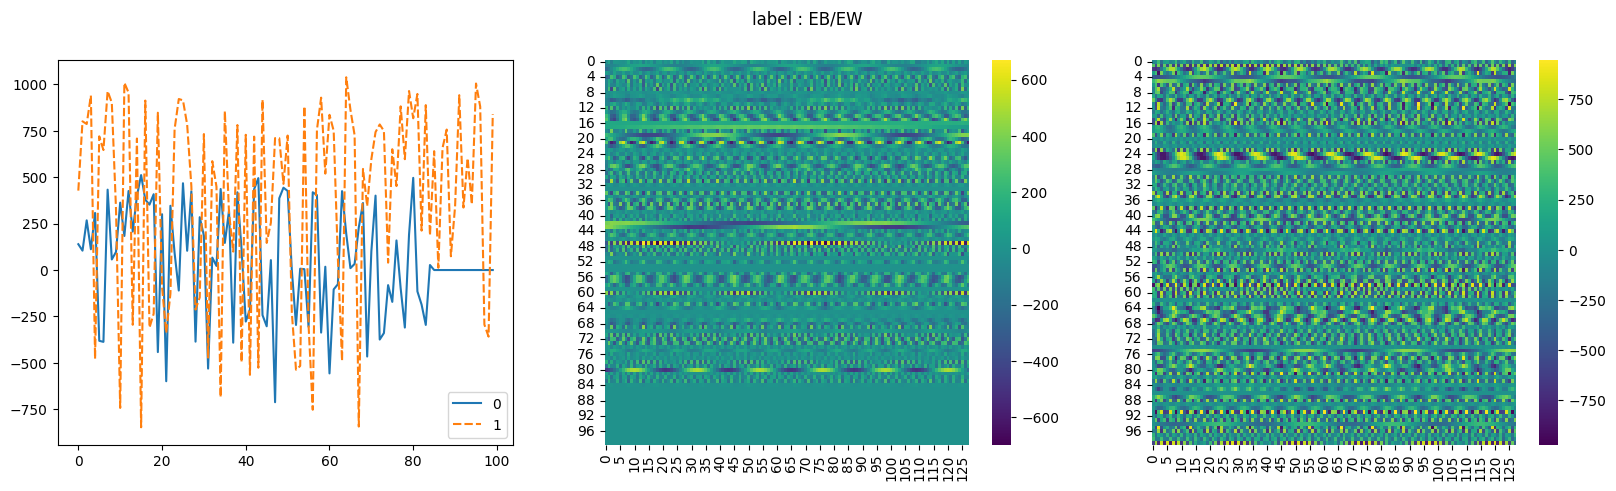

(15, 200, 128)


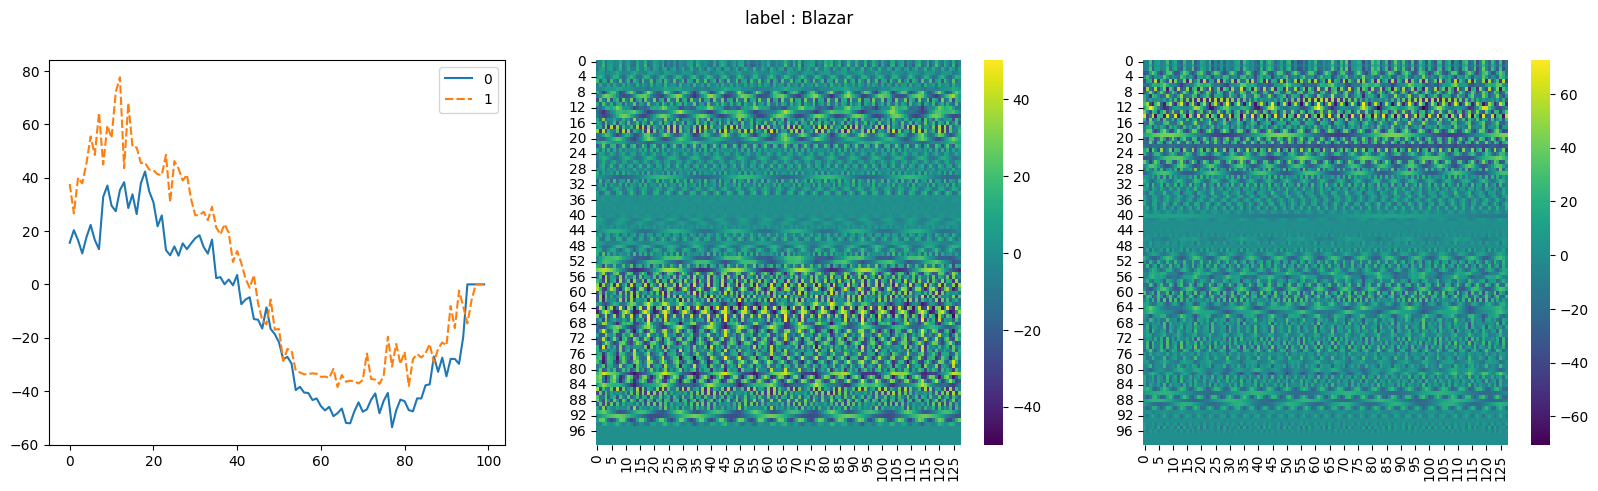

(15, 200, 128)


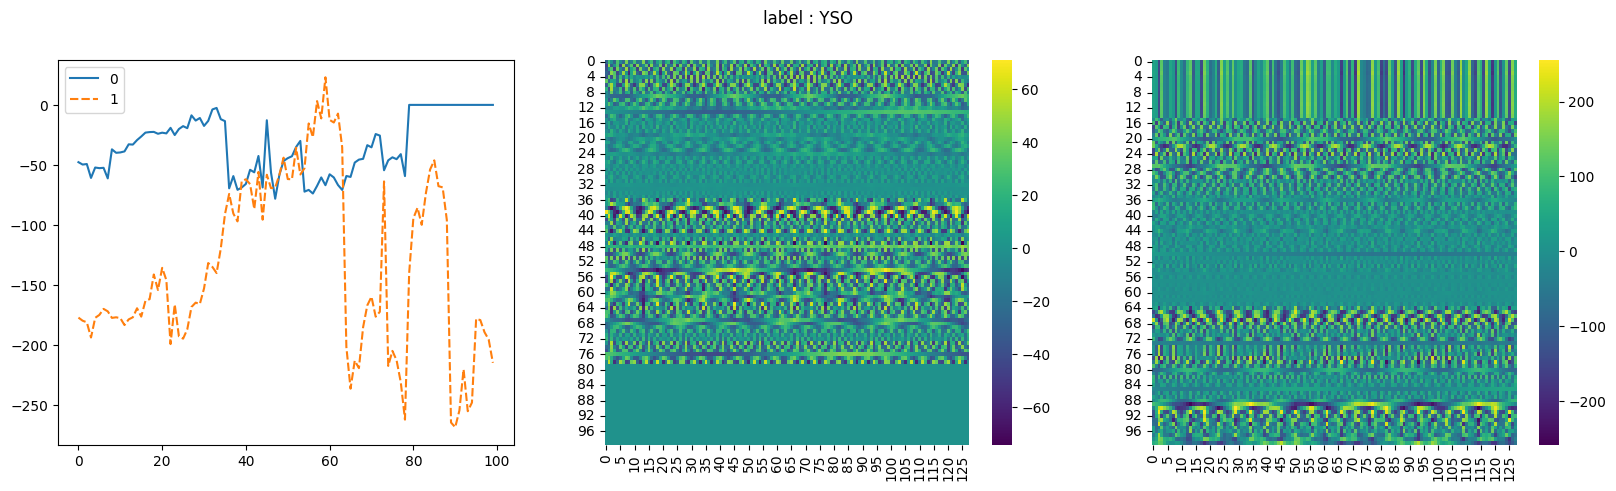

(15, 200, 128)


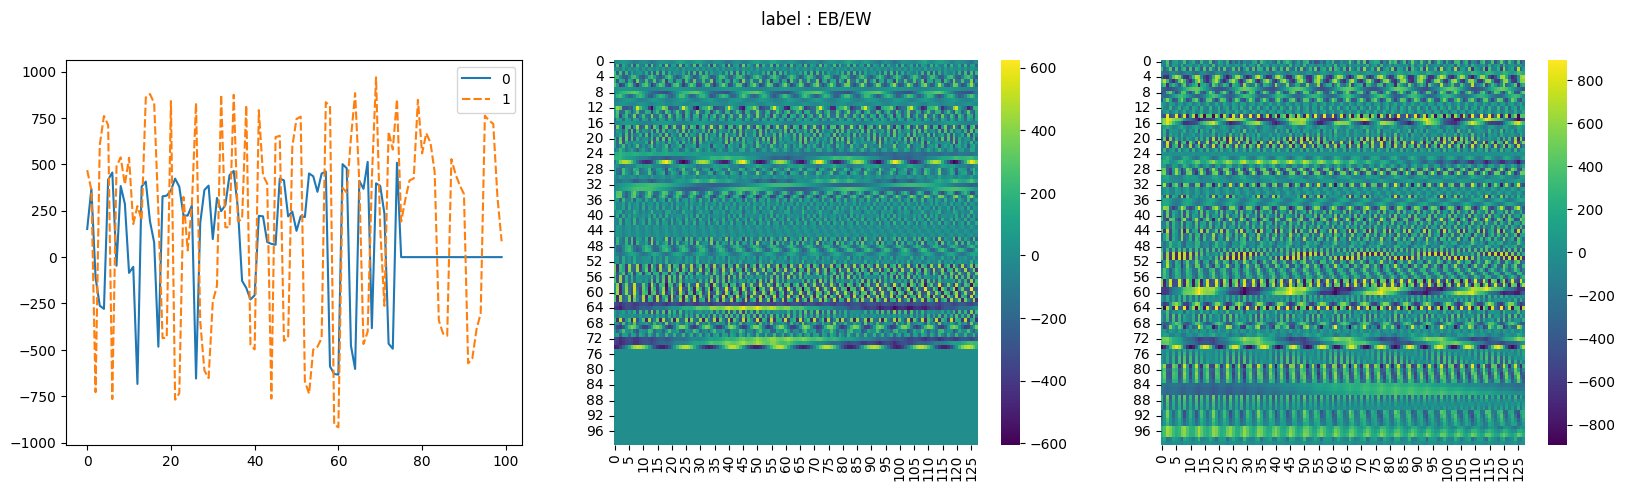

(15, 200, 128)


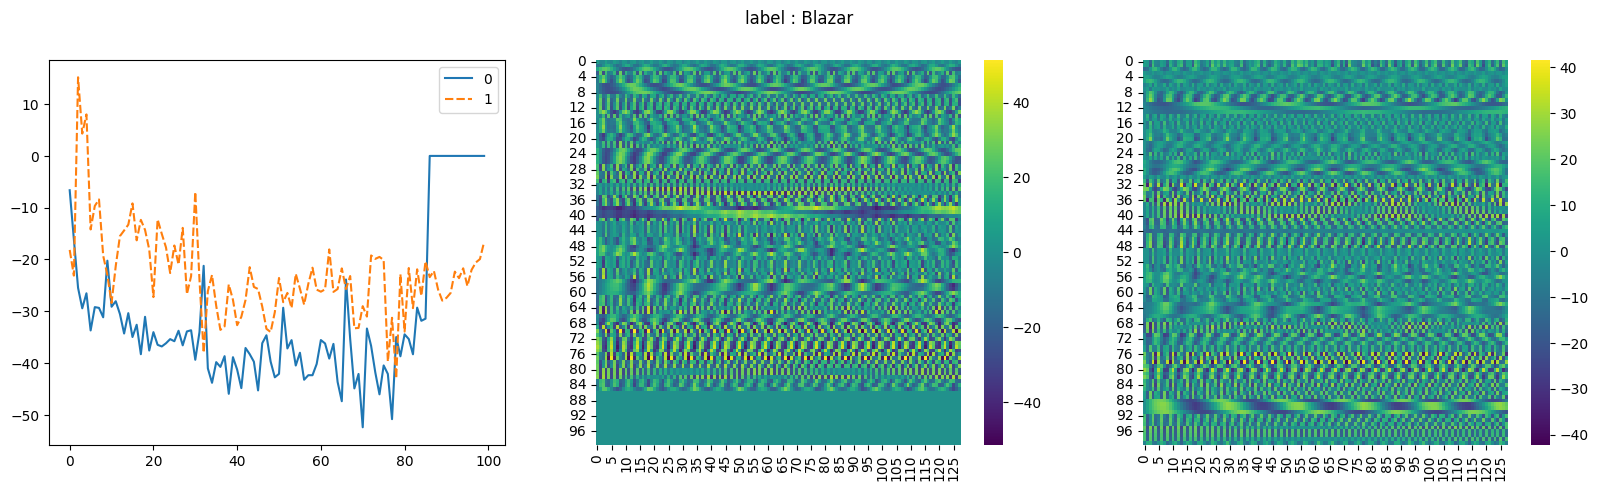

(15, 200, 128)


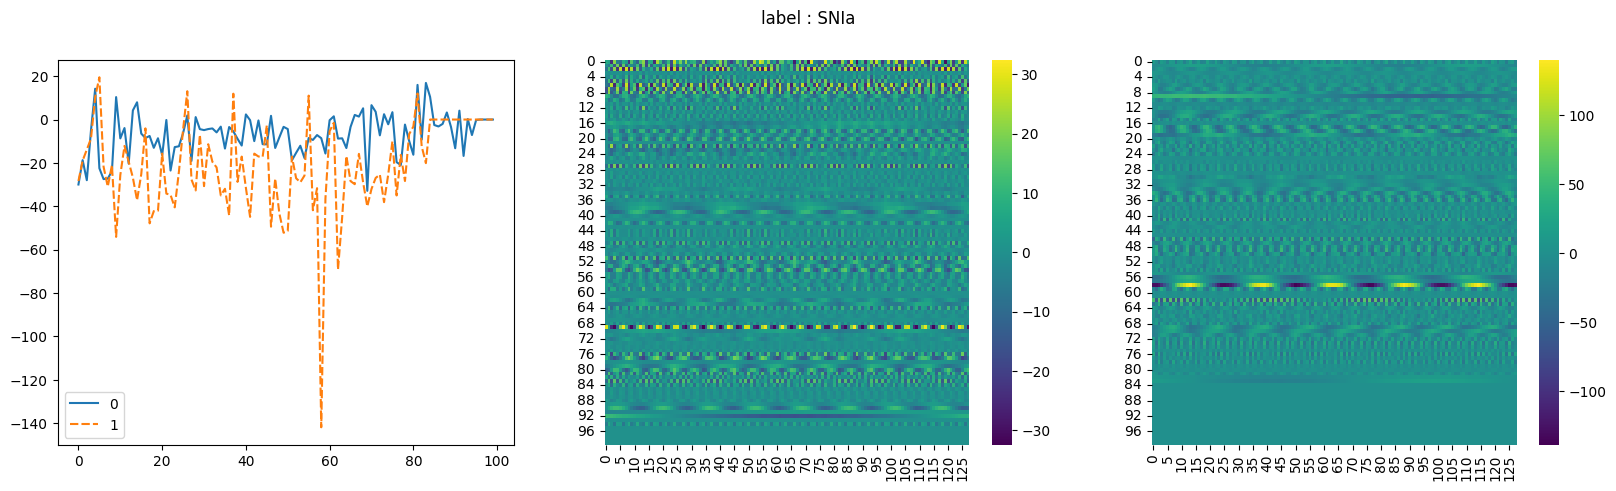

(15, 200, 128)


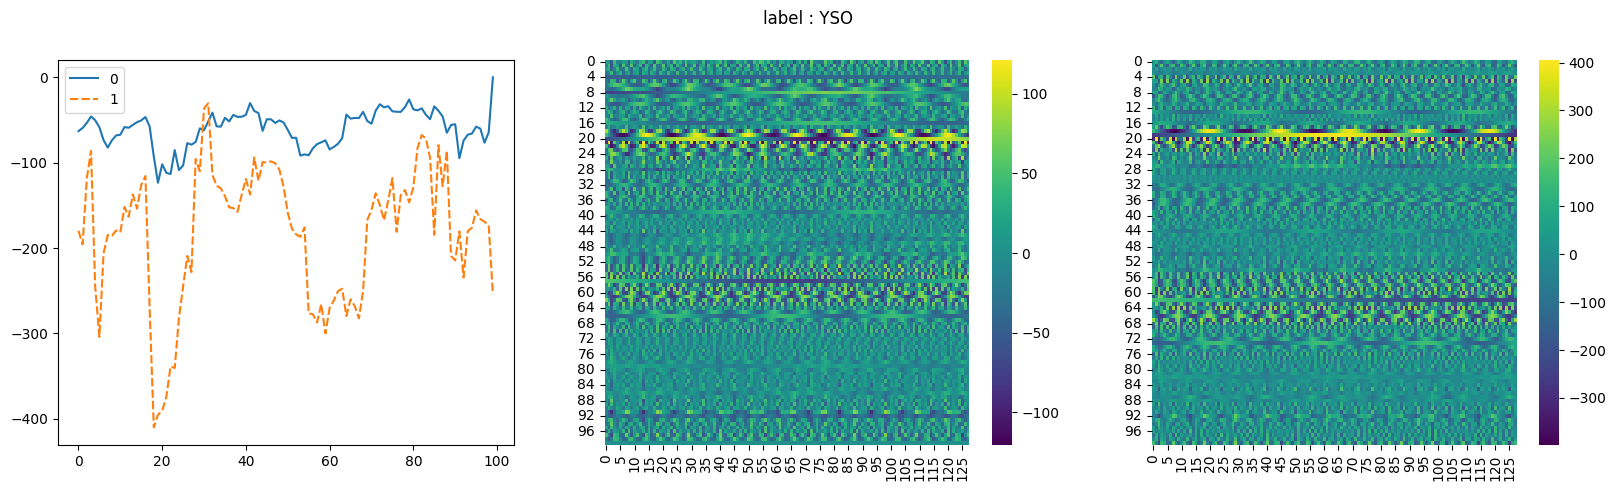

(15, 200, 128)


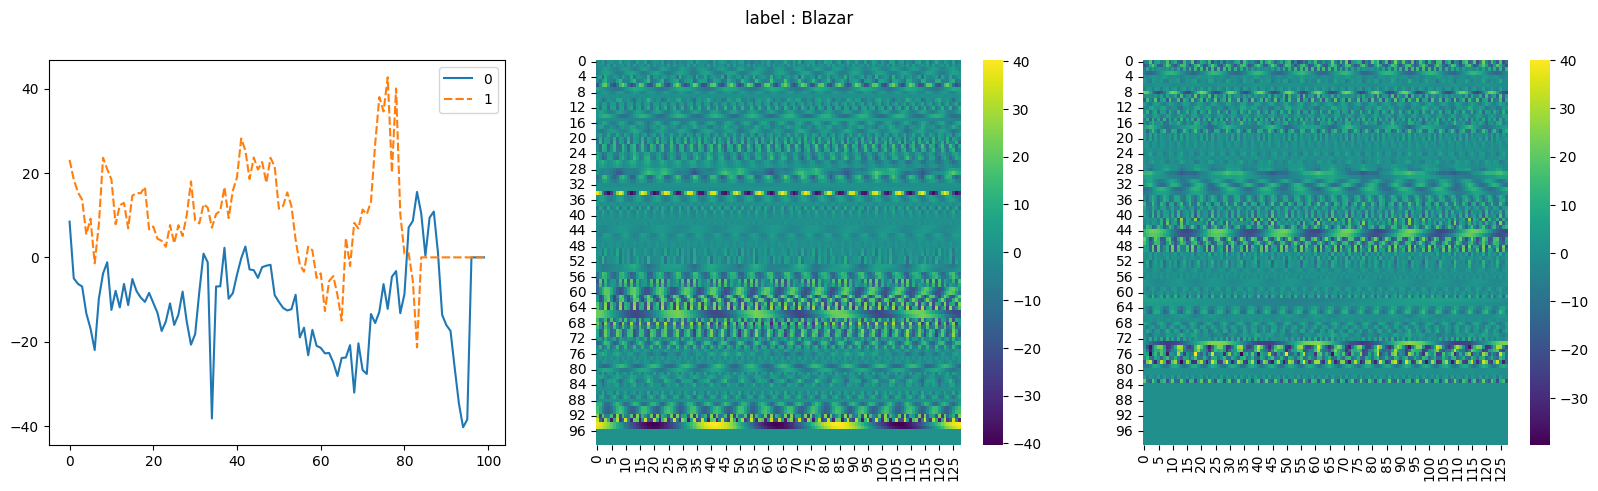

(15, 200, 128)


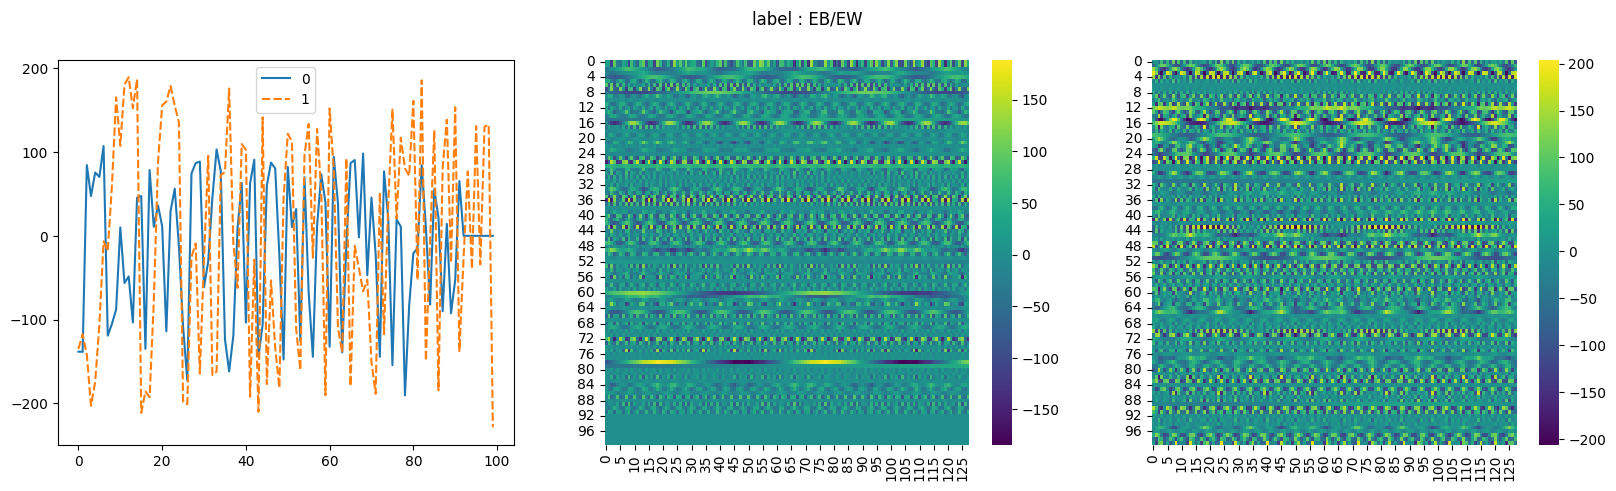

(15, 200, 128)


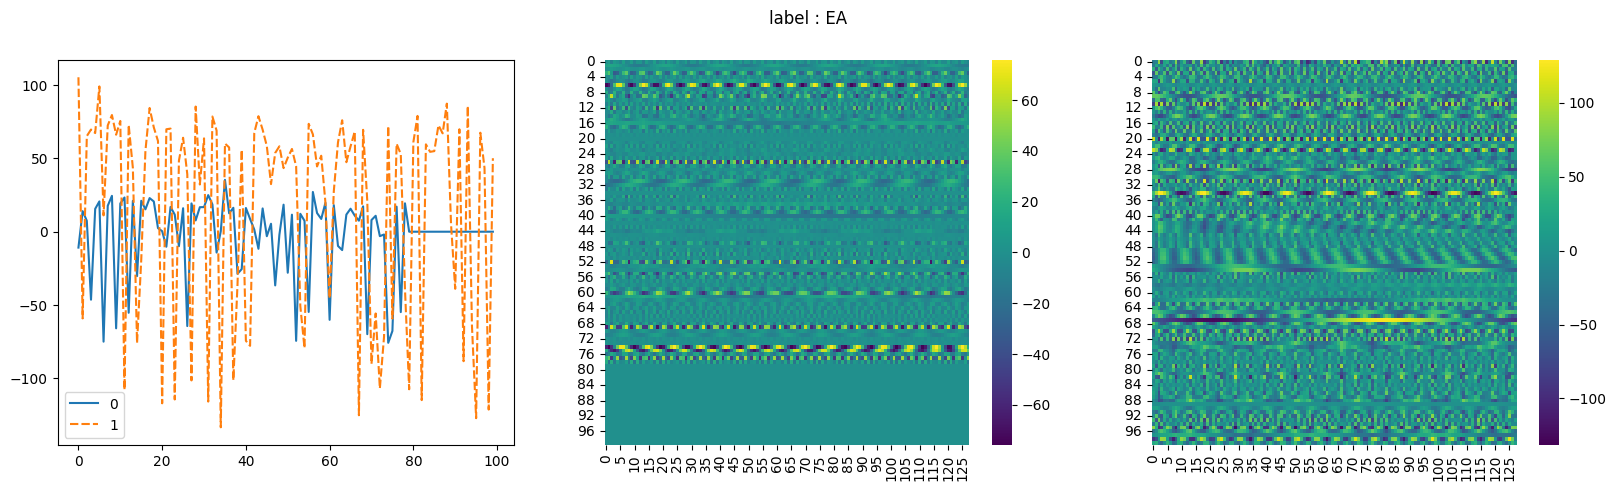

(15, 200, 128)


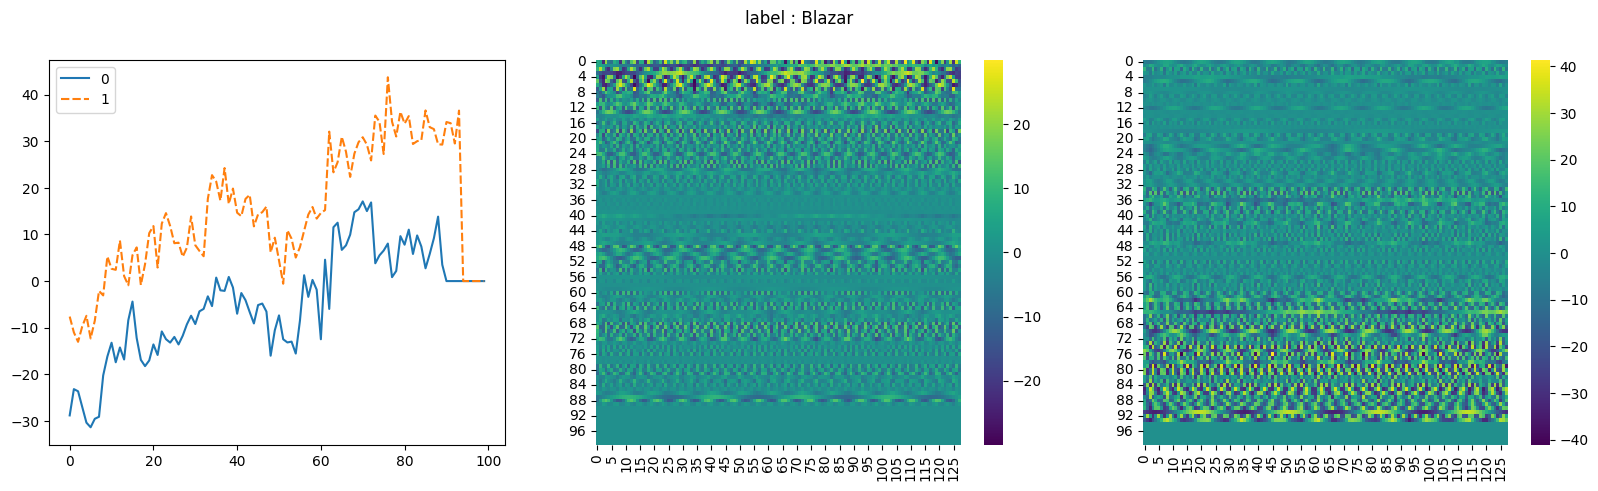

(15, 200, 128)


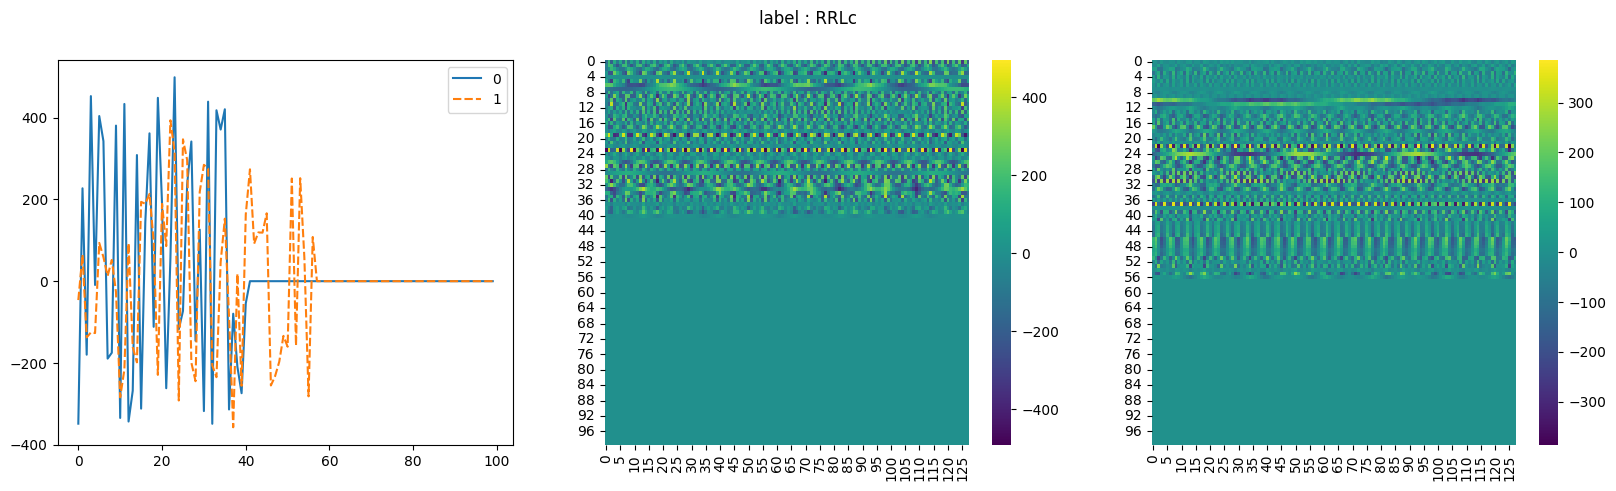

(15, 200, 128)


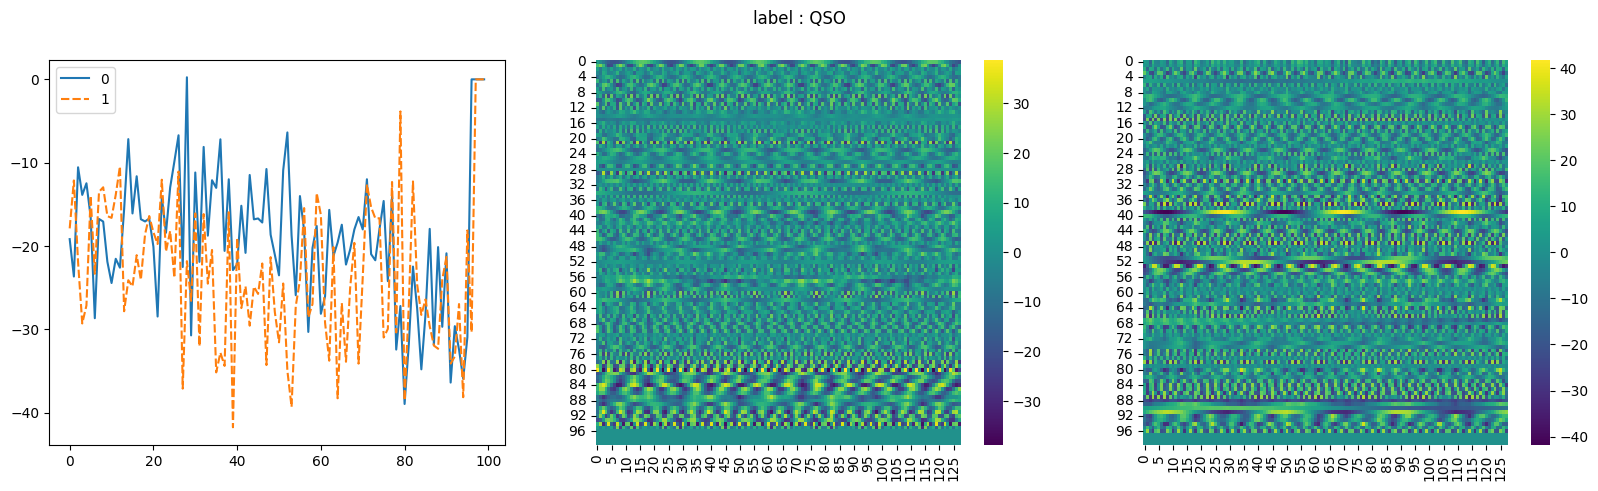

(15, 200, 128)


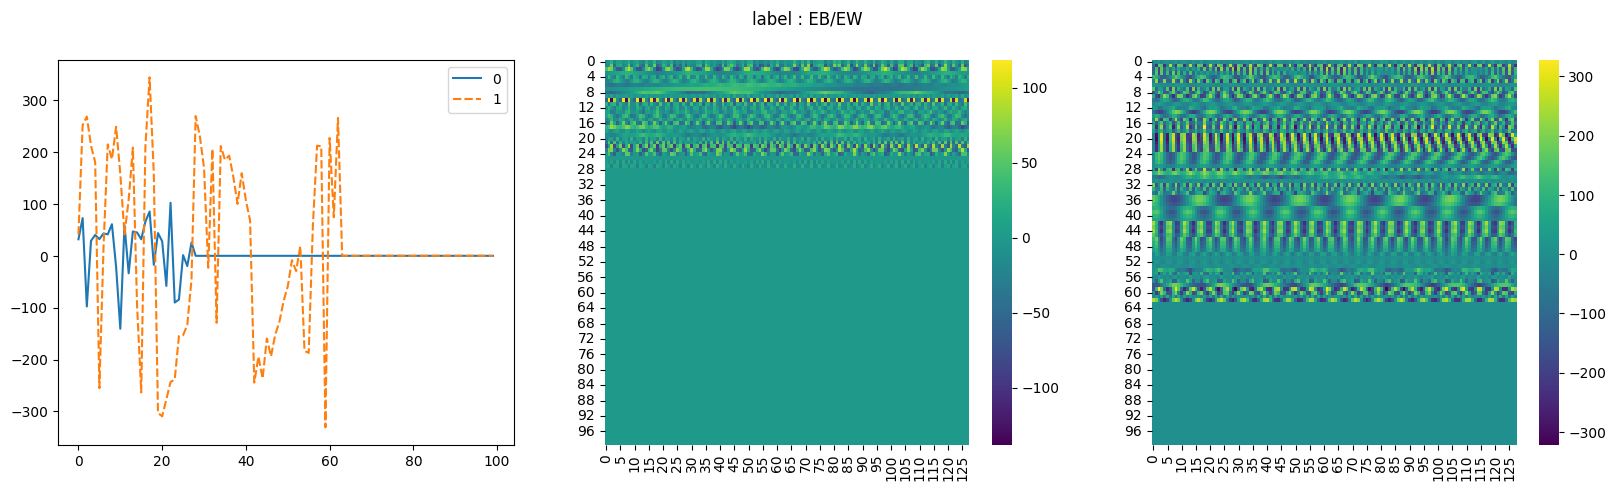

In [928]:
import seaborn as sns
import matplotlib.pyplot as plt
  # Take every second element
show_seqlen = 100
show_emb = 1000
print(save_results[0][0].shape)
#for i in list(np.random.randint(0,5,5)):
for i in list(range(15)):
    fig = plt.figure(figsize = (20,5))
    #sns.lineplot(b1['data'][i,:show_len],ax = fig.add_subplot(131))
    #r_encoded_x = torch.fill_(r_encoded_x == float('inf'),0)
    print(save_results[0][0].shape)
    s = 0
    s = np.random.choice(range(0,10))
    sns.lineplot(save_results[s][3][i,:show_seqlen,:show_emb],ax = fig.add_subplot(131))
    sns.heatmap(save_results[s][0][i,:show_seqlen,:show_emb],ax = fig.add_subplot(132),cmap = 'viridis')
    sns.heatmap(save_results[s][1][i,:show_seqlen,:show_emb],ax = fig.add_subplot(133),cmap = 'viridis')
    #sns.heatmap(rmask[i,:show_len].detach().cpu().numpy(),ax = fig.add_subplot133),cmap = 'viridis')
    plt.suptitle(f'label : {USEFUL_DICT[int(save_results[s][2][i])]}')
    plt.show()